In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from matplotlib.colors import LogNorm 

In [3]:
y3data_old = fits.open('../data/dv/real_map3_desy3_blind.fits')
mymap3 = np.zeros(80)

for i in range(80):
    mymap3[i] = y3data_old[1].data[i][6]

y3data_new = np.load("../data/dv/Y3blind_concatenated_map3_december_8arcmincut/map3_concatenated_Y3_blind_8arcmincut_DECEMBER.npy")

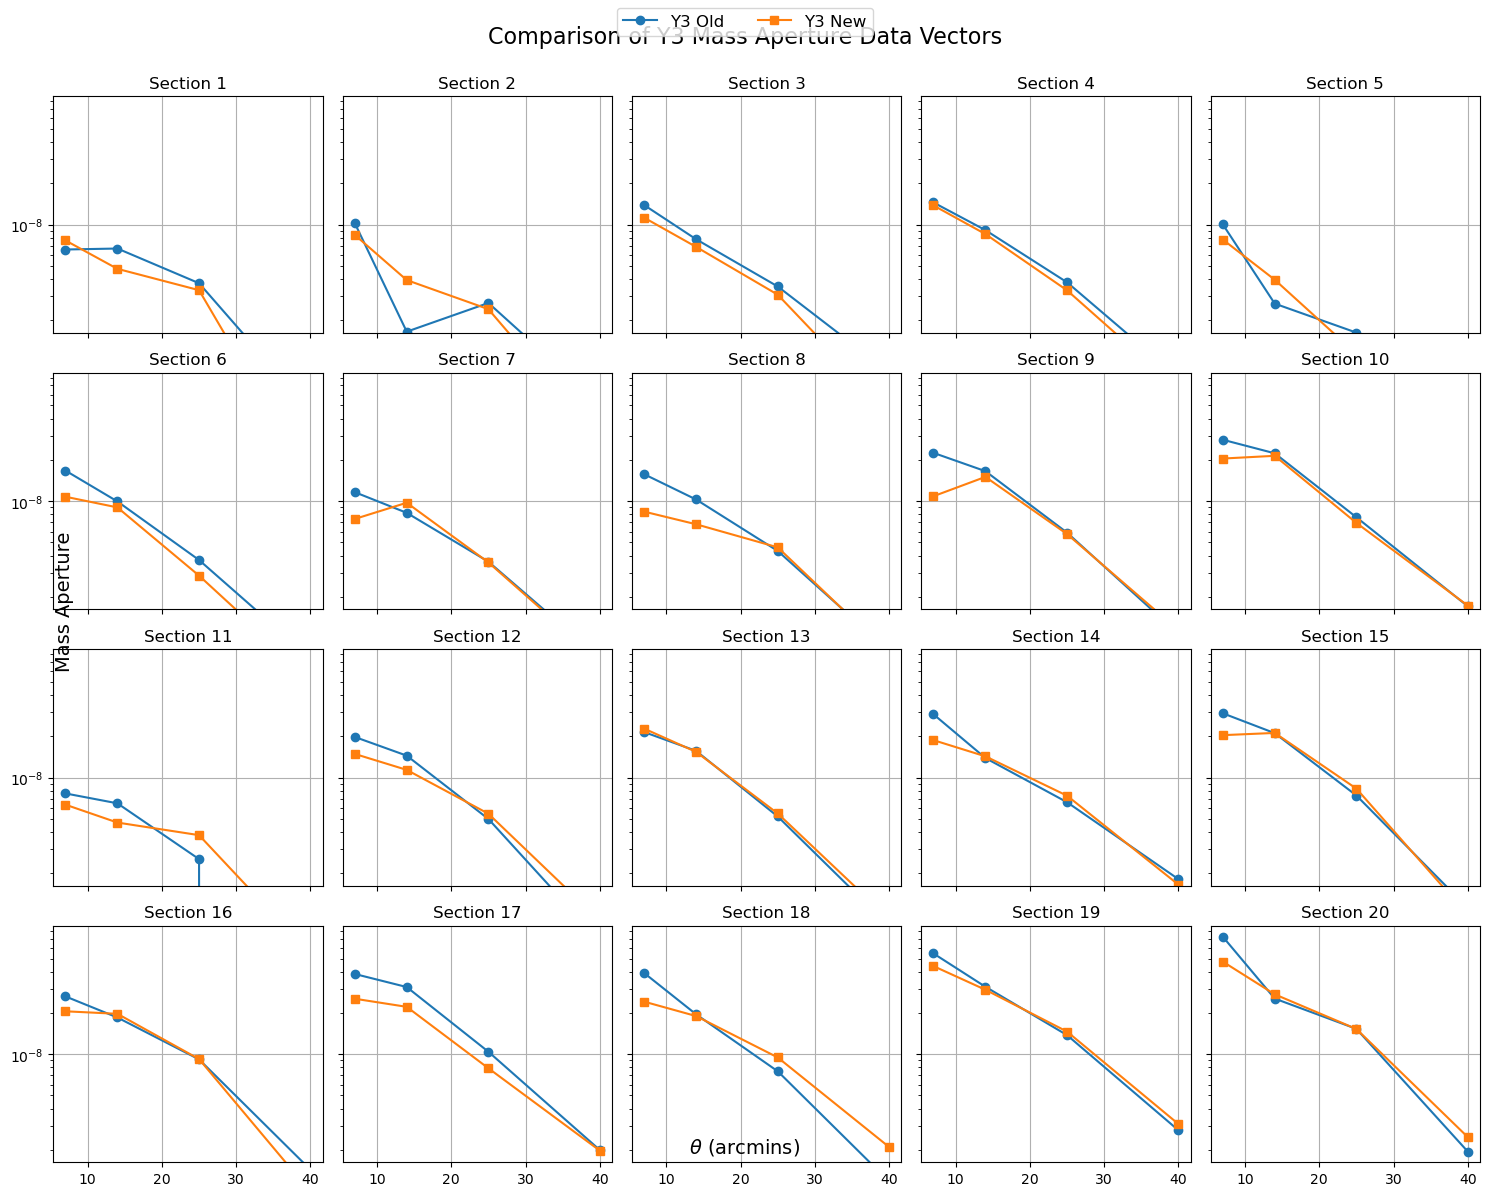

In [5]:
theta = np.array([7, 14, 25, 40])

# Number of sections (panels)
num_sections = 20

# Create a grid of subplots
fig, axes = plt.subplots(4, 5, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.flatten()

# Loop over the sections
for i in range(num_sections):
    # Extract the data for the current section
    start = i * 4
    end = start + 4
    old_data_section = mymap3[start:end]
    new_data_section = y3data_new[start:end]
    
    # Plot the data
    ax = axes[i]
    ax.plot(theta, theta*old_data_section, label='Y3 Old', marker='o')
    ax.plot(theta, theta*new_data_section, label='Y3 New', marker='s')
    
    ax.set_yscale('log')
    # Add a title and grid to each panel
    ax.set_title(f'Section {i + 1}')
    ax.grid(True)

# Set shared x and y labels
fig.text(0.5, 0.04, r'$\theta$ (arcmins)', ha='center', fontsize=14)
fig.text(0.04, 0.5, 'Mass Aperture', va='center', rotation='vertical', fontsize=14)

# Add a single legend outside the grid
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=12)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for legend
plt.suptitle('Comparison of Y3 Mass Aperture Data Vectors', fontsize=16)

# Show the plot
plt.show()